In [ ]:
# Down stream application: PID tuning
import mujoco
import numpy as np
import math
import matplotlib.pyplot as plt
import mediapy as media
from tqdm import tqdm
import time, sys
import datetime
import rootpath

root_dir = rootpath.detect()   # Get the root directory of the project (.git)
from pathlib import Path
sys.path.append(str(Path(root_dir)))

'''
    使用相同的模型文件，参数可以修改
    input: model parameters, experiment time, step time, F1, F2, F1', F2'
    output: tracjectory of state, redering pixels array
'''

class MujocoExperiment(object):
    def __init__(self, model_path, model_type="real_geom"):
        self.model_path = model_path
        self.model = None   # wait for instantiation
        self.data = None
        # self.frames = []
        # self.tracjectory = []
        self.height = 320
        self.width = 400
        self.framerate = 60  # (Hz)
        self.model_type = model_type        # default: swing

    @staticmethod
    def calculate_length(theta1, theta2):
        a1, a2 = 0.25, 0.25
        b1, b2 = 0.21213, 0.1
        d1, d2 = 0.06, 0.10
        beta1, beta2 = np.radians(8.13), np.radians(30)

        C_x, C_y = b1 * np.cos(theta1 - beta1), b1 * np.sin(theta1 - beta1)
        D_x = a1 * np.cos(theta1) + b2 * np.cos(theta1 + theta2 + beta2)
        D_y = a1 * np.sin(theta1) + b2 * np.sin(theta1 + theta2 + beta2)

        l1 = np.hypot(d1 - C_x, 0-C_y)
        l2 = np.hypot(-d2 - D_x, 0-D_y)

        return l1, l2

    def calculate_bias(self, l10, l20):
        if self.model_type == "real_geom":
            l1, l2 = MujocoExperiment.calculate_length(np.pi/2, np.pi/2) # NOTE: the init model state during loading is theta1=90, theta2=90
        else:   # ideal_geom
            l1, l2 = MujocoExperiment.calculate_length(np.pi/2, 0)
        l1_rel = l10 - l1
        l2_rel = l20 - l2
        return l1_rel / 2, l2_rel / 2

    def apply_params(self, params):
        # update model for Experiment
        _model = mujoco.MjModel.from_xml_path(self.model_path)
        _data = mujoco.MjData(_model)
        
        # 设置关节阻尼与刚度
        joint_ids = ["MAA", "MAA_FM", "BAA", "BAA_FM"]
        for joint in joint_ids:
            idx = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, f"RB_{joint}_SlideJoint")
            assert idx != -1, f"Joint {joint} not found in model"
            # print(f"RB_{joint}_SlideJoint id: {idx}")
            stiffness = params['stiffness_BAA' if 'BAA' in joint else 'stiffness_MAA']
            damping = params['damping_BAA' if 'BAA' in joint else 'damping_MAA']
            _model.jnt_stiffness[idx] = stiffness * 2
            _model.dof_damping[idx] = damping * 2

        # 设置肩膀和肘部阻尼
        shoulder_idx = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, "RB_Shoulder")
        elbow_idx = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, "RB_Elbow")
        assert shoulder_idx != -1, "Shoulder joint not found in model"
        assert elbow_idx != -1, "Elbow joint not found in model"
        _model.dof_damping[shoulder_idx] = params['c1_thigh']
        _model.dof_damping[elbow_idx] = params['c2_calf']
        # print(f"RB_Shoulder id: {mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, 'RB_Shoulder')}")
        # print(f"RB_Elbow id: {mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, 'RB_Elbow')}")
        # print RB_Shoulder damping
        # print(f"RB_Shoulder damping: {_model.dof_damping[mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, 'RB_Shoulder')]}")

        # 设置偏置
        l1_bias, l2_bias = self.calculate_bias(params['l10'], params['l20'])
        for joint in joint_ids:
            idx = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, f"RB_{joint}_SlideJoint")
            assert idx != -1, f"Joint {joint} not found in model"
            # print(f"RB_{joint}_SlideJoint id: {idx}")
            _model.qpos_spring[idx] = l1_bias if 'MAA' in joint else l2_bias

        self.model = _model
        self.data = _data
    
    def run(self, params, time_step, duration, ifrender=True):
        self.apply_params(params)
        m, d = self.model, self.data
        # Reset state and time
        mujoco.mj_resetData(m, d)

        results = []
        frames = []
        valid = True        # check if the angle exceeds the limit
        valid_last = True

        with mujoco.Renderer(m, self.height, self.width) as renderer:
            while d.time < duration:
                d.ctrl[:2] = params['P1'] * params['s1'] if d.time < time_step else params['P1_prime'] * params['s1']
                d.ctrl[2:] = params['P2'] * params['s2'] if d.time < time_step else params['P2_prime'] * params['s2']
                
                if self.model_type == "real_geom":
                    theta1 = d.qpos[0] + np.pi / 2
                    theta2 = d.qpos[1] + np.pi / 2
                elif self.model_type == "ideal_geom_swing":     
                    theta1 = d.qpos[0] + np.pi / 2
                    theta2 = d.qpos[1] + 0
                else:   # ideal geom    # ideal_geom_stance, with 2 DOF
                    theta1 = d.qpos[2] + np.pi / 2
                    theta2 = d.qpos[3] + 0
                    
                results.append((d.time, theta1, theta2))
                # check NOTE: only consider the real geom
                # TODO: add threshold to judge the <=
                threshold = math.pi/180     # 1 deg in rad
                # NOTE: Here we wet the range of angle to be [0, pi*2/3]
                if ((np.pi/6+threshold) >= (theta1)) or ((theta1) >= (np.pi/6 + 2/3*np.pi-threshold)) or ((0+threshold) >= (theta2)) or ((theta2) >= (0+2/3*np.pi-threshold)):
                    valid = False

                mujoco.mj_step(m, d)

                if len(frames) < d.time * self.framerate:   # assume the simulation is running much faster than the rendering
                    if ifrender:
                        renderer.update_scene(d, camera="closeup")
                        frames.append(renderer.render())
            if ((np.pi/6+threshold) >= (theta1)) or ((theta1) >= (np.pi/6 + 2/3*np.pi-threshold)) or ((0+threshold) >= (theta2)) or ((theta2) >= (0+2/3*np.pi-threshold)):
                valid_last = False

        time_sim, theta1_sim, theta2_sim = np.array(results).T
        return time_sim, theta1_sim, theta2_sim, frames, valid, valid_last
    
    @staticmethod
    def plot_results(time_sim, theta1_sim, theta2_sim, i=None):
        # 创建一个新的图形
        fig, ax = plt.subplots(figsize=(10, 5))
        # 绘制theta1和theta2的曲线
        ax.plot(time_sim, theta1_sim, label='Theta1')
        ax.plot(time_sim, theta2_sim, label='Theta2')
        # 设置标签和标题
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Angle (degrees)')
        ax.set_title('Joint Angles Over Time')
        # 显示图例
        ax.legend()
        # 返回图形对象
        return fig, ax

if __name__ == "__main__":
    
    # Load the Ancestors Model
    # path = "./models/v2_4/urdf/dog2_4singleLeg_realconstrast.xml"
    # experiment_instance = MujocoExperiment(path, model_type="real_geom")

    path = root_dir + "/models/SingleLeg_ideal.xml"
    experiment_instance = MujocoExperiment(path, model_type="ideal_geom_swing")

    # Model Parameter Set
    stiffness_MAA, stiffness_BAA = 318.76, 315.8
    l10, l20 = 0.174, 0.2562
    damping_MAA, damping_BAA = 11.34, 10.9
    s1, s2 = 0.000654, 0.000637
    c1_thigh, c2_calf = 0.03*0, 0.03*0
    P1 = 10/s1#50*1e3
    P2 = 0
    P1_prime = 1.125/s1#*1e3
    P2_prime = 1/s2#*1e3
    
    exp_num = 100
    np.random.seed(0)
    tic = time.time()

    params = {
        'stiffness_MAA': stiffness_MAA,
        'stiffness_BAA': stiffness_BAA,
        'l10': l10,
        'l20': l20,
        'damping_MAA': damping_MAA,
        'damping_BAA': damping_BAA,
        's1': s1,
        's2': s2,
        'c1_thigh': c1_thigh,
        'c2_calf': c2_calf,
        'P1': P1,
        'P2': P2,
        'P1_prime': P1_prime,
        'P2_prime': P2_prime
    }

    # Run the Experiments
    time_step = 10
    duration_exp = 20  # seconds
    framerate = 60

    experiment_instance.apply_params(params)
    m, d = experiment_instance.model, experiment_instance.data
    # Reset state and time
    mujoco.mj_resetData(m, d)

    results = []
    frames = []
    valid = True        # check if the angle exceeds the limit
    valid_last = True
    ifrender = True
    duration_steady = 10  # seconds, the steady state time
    duration_experiment = 10  # seconds, the experiment time


In [38]:

print("Begin optimization for PID parameters...")
# Evaluate PID parameters using optimization
def evaluate_pid(Kp, Ki, Kd, mode="optimize"):
    # 重置模拟器
    # Reset state and time
    results = []
    frames = []
    dt = m.opt.timestep
    mujoco.mj_resetData(m, d)
    err_sum = [0.0, 0.0]
    last_err = [0.0, 0.0]
    total_error = 0.0
    error_list = []
    with mujoco.Renderer(m, experiment_instance.height, experiment_instance.width) as renderer:
        while d.time < duration_steady + duration_experiment:
            theta1 = d.qpos[0] + np.pi / 2
            theta2 = d.qpos[1] + 0
            u1 = 0
            u2 = 0
            l1, l2 = MujocoExperiment.calculate_length(theta1, theta2)
            l1_target, l2_target = MujocoExperiment.calculate_length(math.pi/2, 0)
            if d.time >= duration_steady:
                err1 = l1_target - l1
                err2 = l2_target - l2
                err_sum[0] += err1 * dt
                err_sum[1] += err2 * dt
                derr1 = (err1 - last_err[0]) / dt
                derr2 = (err2 - last_err[1]) / dt
                u1 = Kp * err1 + Ki * err_sum[0] + Kd * derr1
                u2 = Kp * err2 + Ki * err_sum[1] + Kd * derr2
                # limit u1, u2 in [-100, 100]
                u1 = np.clip(u1, -100, 100)
                u2 = np.clip(u2, -100, 100)
                last_err = [err1, err2]
                d.ctrl[:2] = u1
                d.ctrl[2:] = u2



                total_error += err1**2 + err2**2
                error_list.append(err1**2 + err2**2)
                # print(f"Time: {d.time:.2f}, l1: {l1:.4f}, l2: {l2:.4f}, err1: {err1:.4f}, err2: {err2:.4f}, u1: {u1:.4f}, u2: {u2:.4f}")
            else:
                d.ctrl[:] = 0
            
            # if experiment_instance.model_type == "real_geom":
            #     theta1 = d.qpos[0] + np.pi / 2
            #     theta2 = d.qpos[1] + np.pi / 2
            # elif experiment_instance.model_type == "ideal_geom_swing":     
            #     theta1 = d.qpos[0] + np.pi / 2
            #     theta2 = d.qpos[1] + 0
            
            mujoco.mj_step(m, d)
            if mode == "validate":
                # print(f"Time: {d.time:.2f}, l1: {l1:.4f}, l2: {l2:.4f}")
                if len(frames) < d.time * experiment_instance.framerate:   # assume the simulation is running much faster than the rendering
                    if ifrender:
                        renderer.update_scene(d, camera="closeup")
                        frames.append(renderer.render())
                results.append((d.time, theta1, theta2, u1, u2))
        if mode == "validate":
            time_sim, theta1_sim, theta2_sim, u1, u2 = np.array(results).T
            return time_sim, theta1_sim, theta2_sim, u1, u2, frames
        else:
            return np.mean(np.array(error_list))#*1000

from scipy.optimize import minimize, differential_evolution

def pid_objective(x):
    Kp, Ki, Kd = x
    # Evaluate the PID parameters
    res = evaluate_pid(Kp, Ki, Kd)
    print(f"Evaluating PID: Kp={Kp}, Ki={Ki}, Kd={Kd}, Total Error={res}")
    return res

# 初始猜测
x0 = [100.0, 0.0, 2.0]

time_init, theta1_init, theta2_init, u1_init, u2_init, frames_init = evaluate_pid(*x0, mode="validate")

# 加边界限制
bounds = [(1, 10000), (0, 1000), (0, 100)]

# res = minimize(pid_objective, x0, bounds=bounds, method='L-BFGS-B')
res = differential_evolution(pid_objective, bounds=bounds, popsize=10, disp=True)

print("Best PID:", res.x)

# record the best result
time_best, theta1_best, theta2_best, u1_best,  u2_best, frames_best = evaluate_pid(*res.x, mode="validate")
# print(time_best)

# show video
# media.show_video(frames, fps=framerate)

print(f"Simulation finished at: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
dt_str = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
# video_filename = root_dir + f"/src/application/PID/video/PID_{dt_str}.mp4"
# media.write_video(video_filename, frames, fps=framerate)


Begin optimization for PID parameters...
Evaluating PID: Kp=4693.349806024599, Ki=514.7019316487305, Kd=12.354662544465846, Total Error=2.1957183060666828e-05
Evaluating PID: Kp=6376.060828088932, Ki=638.4890059717436, Kd=95.90635644075637, Total Error=1.6255863167009866e-05
Evaluating PID: Kp=5457.064178269722, Ki=569.2107607324517, Kd=28.248188160664967, Total Error=1.808477674345737e-05
Evaluating PID: Kp=358.94679404362796, Ki=464.40980517743253, Kd=64.08064145727887, Total Error=0.00014792084212120099
Evaluating PID: Kp=80.09955414799151, Ki=114.94775395423545, Kd=9.831998672442431, Total Error=0.000773576193517722
Evaluating PID: Kp=1555.974469093554, Ki=325.00468588637887, Kd=22.84412481282435, Total Error=6.752752126024896e-05
Evaluating PID: Kp=8772.346986373324, Ki=183.09846003055617, Kd=57.225571205960755, Total Error=1.576600025418363e-05
Evaluating PID: Kp=7408.250428456387, Ki=812.313440557444, Kd=80.56988738389103, Total Error=1.3510434364085554e-05
Evaluating PID: Kp=39

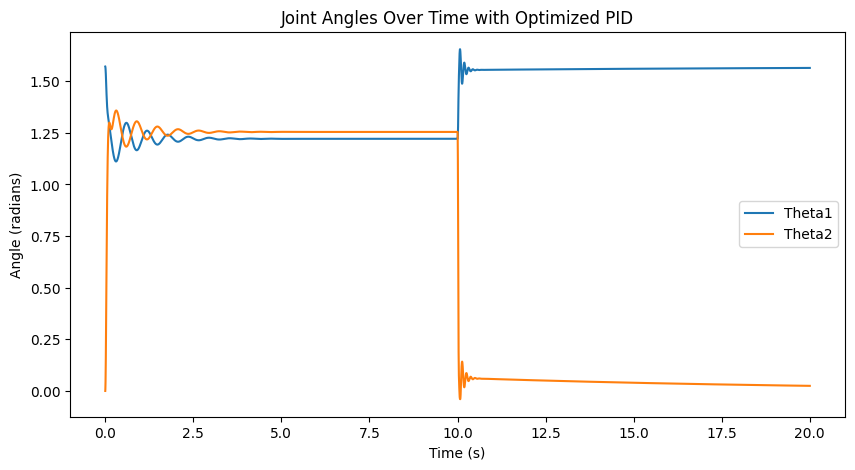

In [39]:

# plot
plt.figure(figsize=(10, 5))
plt.plot(time_best, theta1_best, label='Theta1')
plt.plot(time_best, theta2_best, label='Theta2')
# plt.plot(time_init, theta1_init, label='Theta1 Initial', linestyle='--')
# plt.plot(time_init, theta2_init, label='Theta2 Initial', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Angle (radians)')
plt.title('Joint Angles Over Time with Optimized PID')
plt.legend()
plt.show()


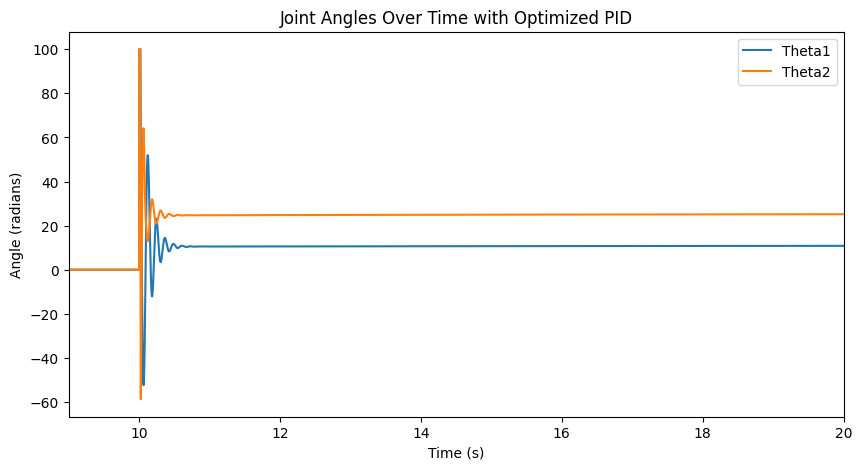

In [43]:

# plot
plt.figure(figsize=(10, 5))
plt.plot(time_best, u1_best, label='Theta1')
plt.plot(time_best, u2_best, label='Theta2')
# plt.plot(time_init, theta1_init, label='Theta1 Initial', linestyle='--')
# plt.plot(time_init, theta2_init, label='Theta2 Initial', linestyle='--')
plt.xlim(duration_steady-1, duration_steady + duration_experiment)

plt.xlabel('Time (s)')
plt.ylabel('Angle (radians)')
plt.title('Joint Angles Over Time with Optimized PID')
plt.legend()
plt.show()


In [21]:
time_best.shape

(60000,)

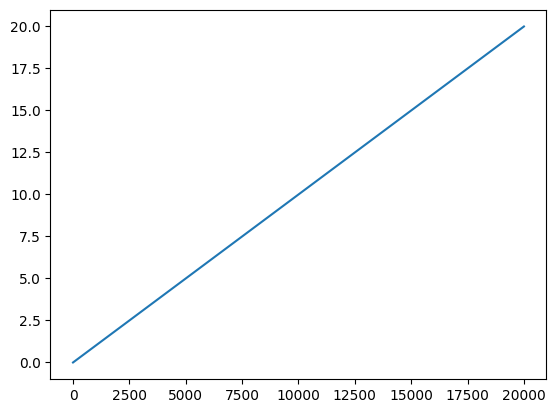

In [7]:
plt.plot(time_best, label='time')

In [44]:
media.show_video(frames_best, fps=framerate)

This browser does not support the video tag.
